### Mounting Trive V2

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 317ms
Checked 140 packages in 2ms


In [2]:
# Mounting Drive
import pandas as pd
import re
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Hugging Face Auth
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_KEY'))

In [4]:
# Loading Model
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("/content/drive/My Drive/DataThon_Data_2026/tribev2_cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")
print("Model loaded")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-05 01:25:54 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access pu

config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-05 01:26:02 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

Model loaded


In [5]:
# Loading the CSV
from google.colab import files

df_data = pd.read_csv('/content/drive/My Drive/DataThon_Data_2026/Datasets/cleaned_tweets.csv')
tweets = df_data['cleaned_tweet'].tolist()
emojis = df_data['label'].tolist()

print(f"Total: {len(tweets)} tweets")
print(f"Labels: {set(emojis)}")


Total: 225331 tweets
Labels: {'relaxed', 'sob', 'weary', 'yum', 'flushed', 'blush', 'grin', 'smirk', 'wink', 'heart_eyes'}


In [6]:
# Filtering Confused Pairs
target = ['sob', 'weary', 'blush', 'heart_eyes', 'yum']

filtered_tweets = []
filtered_emojis = []

for tweet, emoji in zip(tweets, emojis):
    if emoji.strip() in target:
        filtered_tweets.append(tweet.strip())
        filtered_emojis.append(emoji.strip())

print(f"Filtered: {len(filtered_tweets)} tweets")


Filtered: 156257 tweets


In [ ]:
# Balancing
from collections import defaultdict

CAP = 10
balanced_tweets = []
balanced_emojis = []
counts = defaultdict(int)

for tweet, emoji in zip(filtered_tweets, filtered_emojis):
    if counts[emoji] < CAP:
        balanced_tweets.append(tweet)
        balanced_emojis.append(emoji)
        counts[emoji] += 1

print(dict(counts))

{'heart_eyes': 5, 'yum': 5, 'sob': 5, 'blush': 5, 'weary': 5}


## Predict brain responses to pure text

In [31]:
import numpy as np
import tempfile, os

brain_features = []
failed_indices = []

for i, tweet in enumerate(balanced_tweets):
    with tempfile.NamedTemporaryFile(
        mode='w', suffix='.txt', delete=False, encoding='utf-8'
    ) as f:
        f.write(tweet)
        tmp_path = f.name

    try:
        df_tweet = model.get_events_dataframe(text_path=tmp_path)
        preds_tweet, _ = model.predict(events=df_tweet)
        brain_features.append(preds_tweet.mean(axis=0))
    except Exception as e:
        print(f"Failed on tweet {i}: {e}")
        brain_features.append(np.zeros(20484))
        failed_indices.append(i)
    finally:
        os.unlink(tmp_path)

    if i % 10 == 0:
        print(f"Progress: {i}/{len(balanced_tweets)}")

brain_features = np.array(brain_features)
print(f"\nDone. Shape: {brain_features.shape}")
print(f"Failed: {len(failed_indices)} tweets")

[01:59:07 WARNING] Removing extractor video as there are no corresponding events
[01:59:07 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
  0%|          | 0/3 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Computing word embeddings: 100%|██████████| 4/4 [00:05<00:00,  1.25s/it]
[02:13:48 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[02:13:51 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-05 02:13:51 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[02:13:51 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.39s/it]
INFO - Predicted 5 / 100 segments (5.0% kept)
INFO:tribev2.demo_utils:Predicted 5 / 100 segments (5.0% kept)



Done. Shape: (25, 20484)
Failed: 0 tweets


In [ ]:
# Saving Model
np.save('/content/drive/My Drive/DataThon_Data_2026/npy_files/brain_features.npy', brain_features)
np.save('/content/drive/My Drive/DataThon_Data_2026/npy_files/balanced_emojis.npy',
        np.array(balanced_emojis))

print("Saved to Google Drive")
print(f"brain_features.npy: {brain_features.shape}")
print(f"balanced_emojis.npy: {len(balanced_emojis)} labels")

Saved to Google Drive
brain_features.npy: (25, 20484)
balanced_emojis.npy: 25 labels


Saved sob
Saved weary
Saved blush
Saved heart_eyes
Saved yum


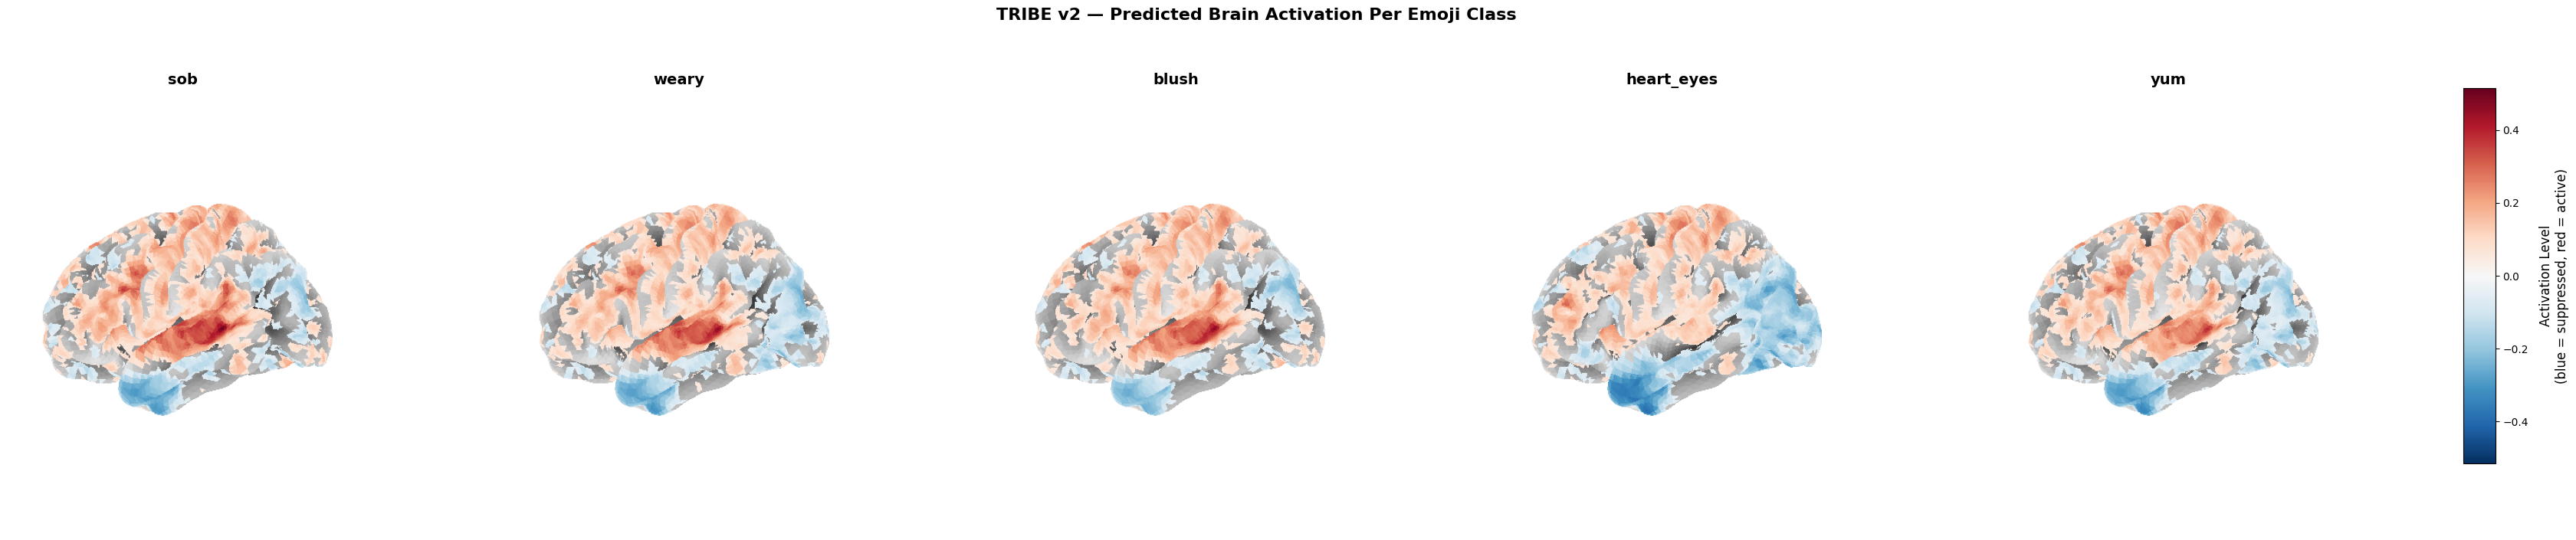

Saved all_emoji_brains.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from nilearn import plotting, datasets
import os

brain_features = np.load('/content/drive/My Drive/DataThon_Data_2026/npy_files/brain_features.npy')
balanced_emojis = np.load('/content/drive/My Drive/DataThon_Data_2026/npy_files/balanced_emojis.npy')

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
emoji_classes = ['sob', 'weary', 'blush', 'heart_eyes', 'yum']
save_dir = '/content/drive/My Drive/DataThon_Data_2026/npy_files/'
cmap_name = 'RdBu_r'

# Computing per emoji averages
all_maps = []
for emoji in emoji_classes:
    indices = np.where(balanced_emojis == emoji)[0]
    all_maps.append(brain_features[indices].mean(axis=0))

# Symmetric scale
abs_max = np.percentile([np.abs(m).max() for m in all_maps], 95)
global_min = -abs_max
global_max = abs_max

# Saving each brain
for emoji, avg_brain_map in zip(emoji_classes, all_maps):
    out_path = os.path.join(save_dir, f'{emoji}_brain.png')

    plotting.plot_surf_stat_map(
        fsaverage['pial_left'],
        avg_brain_map[:10242],
        hemi='left',
        view='lateral',
        colorbar=False,
        cmap=cmap_name,
        vmin=global_min,
        vmax=global_max,
        threshold=0.05,
        bg_map=fsaverage['sulc_left'],
        bg_on_data=False,
        output_file=out_path
    )
    plt.close('all')
    print(f"Saved {emoji}")

# Stitching Brain
fig, axes = plt.subplots(1, 5, figsize=(35, 7))
fig.suptitle(
    'TRIBE v2 — Predicted Brain Activation Per Emoji Class',
    fontsize=16, fontweight='bold', y=1.0
)

for ax, emoji in zip(axes, emoji_classes):
    img = mpimg.imread(os.path.join(save_dir, f'{emoji}_brain.png'))
    ax.imshow(img)
    ax.set_title(emoji, fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 0.94, 0.95])

# Shared colorbar
norm = mcolors.TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)
sm = cm.ScalarMappable(cmap=cmap_name, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.95, 0.15, 0.012, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Activation Level\n(blue = suppressed, red = active)',
               fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

plt.savefig(
    os.path.join(save_dir, 'all_emoji_brains.png'),
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Saved all_emoji_brains.png")

In [48]:
from scipy.spatial.distance import cosine

emoji_profiles = {}
for emoji in emoji_classes:
    indices = np.where(balanced_emojis == emoji)[0]
    emoji_profiles[emoji] = brain_features[indices].mean(axis=0)

# Compare confused pairs
pairs = [
    ('sob', 'weary'),
    ('blush', 'heart_eyes'),
    ('sob', 'yum'),
    ('weary', 'yum')
]

print(f"{'Pair':<25} {'Brain Distance':>15}")
print("─" * 42)
for e1, e2 in pairs:
    dist = cosine(emoji_profiles[e1], emoji_profiles[e2])
    print(f"{e1} vs {e2:<20} {dist:.4f}")

Pair                       Brain Distance
──────────────────────────────────────────
sob vs weary                0.0387
blush vs heart_eyes           0.2356
sob vs yum                  0.0389
weary vs yum                  0.0177
